# Demo: Covseisnet

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/demos/08a_demo_covseisnet.ipynb)

In [1]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'covseisnet': 'covseisnet',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✗ covseisnet not found
✓ obspy is already installed

Installing missing packages: covseisnet


✓ Installation complete!


Set parameters to download seismic data of the Piton de la Fournaise volcano seismic network

In [18]:
import covseisnet as csn
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from obspy.clients.fdsn import Client

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

client = Client("RESIF")

signal_duration_sec = 12 * 3600
t = UTCDateTime("2010-10-14T08:00:00.00")

list_stations = [
    "SNE",
    "FOR",
    "UV01",
    "UV02",
    "UV03",
    "UV04",
    "UV05",
    "UV06",
    "UV07",
    "UV08",
    "UV09",
    "UV10",
    "UV11",
    "UV12",
    "UV13",
    "UV14",
    "UV15",
]

Download the data and print results

In [19]:
# ------------------------------------------------------------
# Download data
# ------------------------------------------------------------

stream = csn.arraystream.ArrayStream()

print("Starting waveform download...\n")

for sta in list_stations:

    print(f"Downloading station: {sta}")

    try:

        st = client.get_waveforms(
            "YA",
            sta,
            "00",
            "HHZ",
            t,
            t + signal_duration_sec,
        )

        stream.append(st[0])

        print(f"  -> SUCCESS ({len(st[0].data)} samples)")

    except Exception as e:

        print(f"  -> FAILED for station {sta}")
        print(f"     Error: {e}")

print("\nDownload finished.")
print(f"Number of traces successfully downloaded: {len(stream)}")

# ------------------------------------------------------------
# Downsample data to 25 Hz
# ------------------------------------------------------------

print("\nDecimating data by factor 4...")
stream.decimate(4)

# ------------------------------------------------------------
# Synchronize traces
# ------------------------------------------------------------

print("Synchronizing traces...")

stream = stream.synchronize(
    start=t,
    duration_sec=signal_duration_sec,
    method="linear",
)

# ------------------------------------------------------------
# Final stream summary
# ------------------------------------------------------------

print("\nFinal synchronized stream:\n")
print(stream)

Starting waveform download...

  -> SUCCESS (3181596 samples)
  -> SUCCESS (3180796 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)
  -> SUCCESS (4320001 samples)

Download finished.
Number of traces successfully downloaded: 17

Decimating data by factor 4...
Synchronizing traces...

Final synchronized stream:

17 Trace(s) in Stream:
YA.SNE.00.HHZ  | 2010-10-14T08:00:00.000000Z - 2010-10-14T19:59:59.960000Z | 25.0 Hz, 1080000 samples
YA.FOR.00.HHZ  | 2010-10-14T08:00:00.000000Z - 2010-10-14T19:59:59.960000Z | 25.0 Hz, 1080000 samples
YA.UV01.00.HHZ | 2010-10-14T08:00:00.000000Z - 2010-10-14T19:59:5

Set Parameters and Apply Pre-Processing 

In [20]:
# calculate covariance from stream
window_duration_sec = 20
average = 15

overlap=0.5
preproc_spectral_secs = window_duration_sec * average * overlap
stream.preprocess(domain="spectral", method="onebit", window_duration_sec=preproc_spectral_secs)
        
## add temporal normalization
stream.preprocess(domain="temporal", method="smooth", smooth_length=int(preproc_spectral_secs))

Compute the Seismic Network Covariance Matrix and Print Results

In [21]:
times, frequencies, covariances = csn.covariancematrix.calculate(
    stream, window_duration_sec, average
)

In [22]:
print(covariances.shape)

(615, 999, 17, 17)


Compute the Spectral Width of the Covariance Matrix and Print Results

In [23]:
spectral_width = covariances.coherence(kind="spectral_width")
print(spectral_width.shape)

(615, 999)


Plot the Spectral Width Time Series

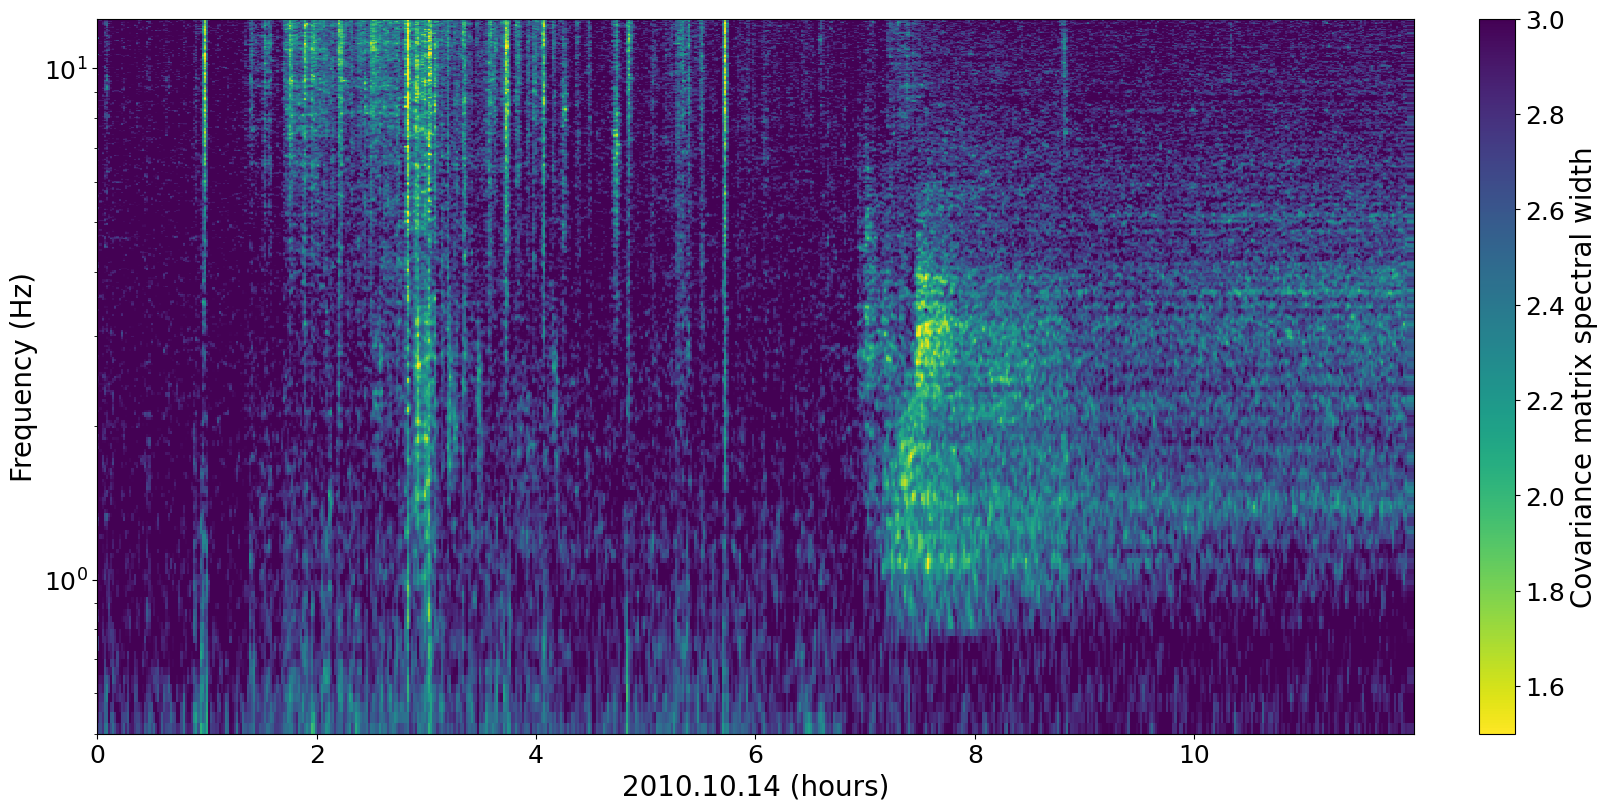

In [30]:
# show network covariance matrix spectral width
fig, ax = plt.subplots(1, figsize=(16, 8),constrained_layout=True)
img = ax.pcolormesh(
    times / 3600, frequencies, spectral_width.T, rasterized=True, cmap="viridis_r", vmin=1.5, vmax=3
)
ax.set_ylim([0, stream[0].stats.sampling_rate / 2])
ax.set_yscale("log")
ax.set_ylim([0.5, stream[0].stats.sampling_rate / 2])
# increase tick label size
ax.tick_params(axis="both", labelsize=18)
ax.set_xlabel("2010.10.14 (hours)", fontsize=20)
ax.set_ylabel("Frequency (Hz)", fontsize=20)
cbar = plt.colorbar(img)
cbar.set_label("Covariance matrix spectral width", fontsize=20)
cbar.ax.tick_params(labelsize=18)